<a href="https://colab.research.google.com/github/KDY-RiskManager/risk-management-portfolio/blob/main/02-credit-risk/credit_risk_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

fontpath = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(fontpath)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
import pandas as pd
import numpy as np

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
columns = ['checking_account','duration','credit_history','purpose','credit_amount',
           'savings','employment','installment_rate','personal_status','other_debtors',
           'residence_since','property','age','other_installment','housing',
           'existing_credits','job','num_dependents','telephone','foreign_worker','target']

df_credit = pd.read_csv(url, sep=' ', header=None, names=columns)
df_credit['target'] = df_credit['target'].map({1:0, 2:1})  # 1=정상(0), 2=부도(1)으로 변환
df_credit.head()

,checking_account,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status,other_debtors,...,property,age,other_installment,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


전체 대출자 수: 1000명
부도율: 30.00%


<Axes: title={'center': '정상(0) vs 부도(1) 분포'}, xlabel='target'>

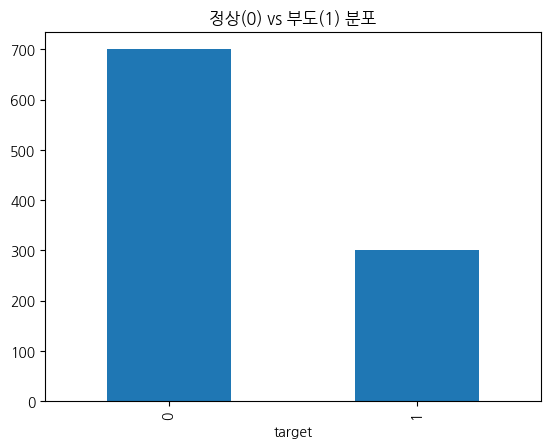

In [3]:
print(f"전체 대출자 수: {len(df_credit)}명")
print(f"부도율: {df_credit['target'].mean()*100:.2f}%")
df_credit['target'].value_counts().plot(kind='bar', title='정상(0) vs 부도(1) 분포')

In [4]:
df_encoded = pd.get_dummies(df_credit, columns=[
    'checking_account','credit_history','purpose','savings','employment',
    'personal_status','other_debtors','property','other_installment',
    'housing','job','telephone','foreign_worker'
], drop_first=True)

print(f"인코딩 전 컬럼 수: {df_credit.shape[1]}, 인코딩 후 컬럼 수: {df_encoded.shape[1]}")
df_encoded.head()

인코딩 전 컬럼 수: 21, 인코딩 후 컬럼 수: 49


,duration,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents,target,checking_account_A12,checking_account_A13,...,property_A124,other_installment_A142,other_installment_A143,housing_A152,housing_A153,job_A172,job_A173,job_A174,telephone_A192,foreign_worker_A202
0,6,1169,4,4,67,2,1,0,False,False,...,False,False,True,True,False,False,True,False,True,False
1,48,5951,2,2,22,1,1,1,True,False,...,False,False,True,True,False,False,True,False,False,False
2,12,2096,2,3,49,1,2,0,False,False,...,False,False,True,True,False,True,False,False,False,False
3,42,7882,2,4,45,1,2,0,False,False,...,False,False,True,False,True,False,True,False,False,False
4,24,4870,3,4,53,2,2,1,False,False,...,True,False,True,False,True,False,True,False,False,False


In [5]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"학습 데이터: {len(X_train)}명, 검증 데이터: {len(X_test)}명")
print(f"학습 데이터 부도율: {y_train.mean()*100:.2f}%, 검증 데이터 부도율: {y_test.mean()*100:.2f}%")

학습 데이터: 700명, 검증 데이터: 300명
학습 데이터 부도율: 30.00%, 검증 데이터 부도율: 30.00%


In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

pd_pred = model.predict_proba(X_test)[:, 1]  # 부도 확률 (PD)

print("PD 예측 완료. 검증 데이터 상위 5명의 예측 부도확률:")
print(pd_pred[:5])

PD 예측 완료. 검증 데이터 상위 5명의 예측 부도확률:
[0.03208126 0.14522436 0.43243192 0.10456987 0.27303843]


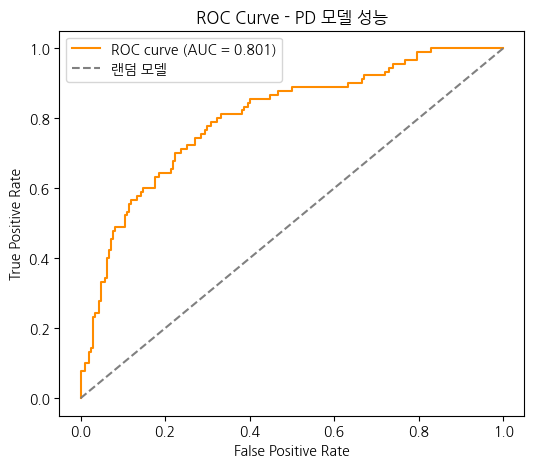

ROC-AUC: 0.8013


In [7]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

auc = roc_auc_score(y_test, pd_pred)
fpr, tpr, thresholds = roc_curve(y_test, pd_pred)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})', color='darkorange')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='랜덤 모델')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - PD 모델 성능')
plt.legend()
plt.show()

print(f"ROC-AUC: {auc:.4f}")

KS statistic: 0.4794


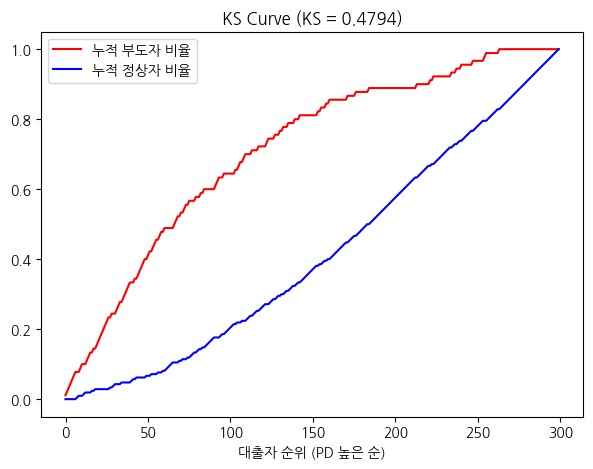

In [8]:
import numpy as np

df_ks = pd.DataFrame({'y_true': y_test.values, 'pd_pred': pd_pred})
df_ks = df_ks.sort_values('pd_pred', ascending=False).reset_index(drop=True)

df_ks['cum_bad'] = (df_ks['y_true'] == 1).cumsum() / (df_ks['y_true'] == 1).sum()
df_ks['cum_good'] = (df_ks['y_true'] == 0).cumsum() / (df_ks['y_true'] == 0).sum()
df_ks['ks'] = df_ks['cum_bad'] - df_ks['cum_good']

ks_stat = df_ks['ks'].max()
print(f"KS statistic: {ks_stat:.4f}")

plt.figure(figsize=(7,5))
plt.plot(df_ks['cum_bad'], label='누적 부도자 비율', color='red')
plt.plot(df_ks['cum_good'], label='누적 정상자 비율', color='blue')
plt.title(f'KS Curve (KS = {ks_stat:.4f})')
plt.xlabel('대출자 순위 (PD 높은 순)')
plt.legend()
plt.show()

In [9]:
df_ecl = X_test.copy()
df_ecl['PD'] = pd_pred
df_ecl['EAD'] = df_credit.loc[X_test.index, 'credit_amount']
df_ecl['duration_months'] = df_credit.loc[X_test.index, 'duration']
df_ecl[['PD', 'EAD', 'duration_months']].head()

,PD,EAD,duration_months
115,0.032081,3578,48
346,0.145224,882,13
328,0.432432,4473,36
974,0.104570,2831,30
587,0.273038,1289,12


In [10]:
LGD = 0.45  # 무담보 개인신용대출 표준 가정 (바젤/IFRS9 실무 기준)
df_ecl['LGD'] = LGD
df_ecl[['PD', 'LGD', 'EAD']].describe()

,PD,LGD,EAD
count,300.000000,3.000000e+02,300.000000
mean,0.300777,4.500000e-01,3435.490000
std,0.233164,1.334494e-15,3139.323895
min,0.008508,4.500000e-01,250.000000
25%,0.104986,4.500000e-01,1387.500000
50%,0.226418,4.500000e-01,2331.000000
75%,0.478759,4.500000e-01,3962.250000
max,0.915647,4.500000e-01,18424.000000


In [11]:
STAGE_THRESHOLD = 0.20  # PD 20% 이상이면 Stage 2 (신용위험 유의적 증가)로 분류

df_ecl['stage'] = np.where(df_ecl['PD'] >= STAGE_THRESHOLD, 'Stage 2', 'Stage 1')

# Lifetime PD 근사치: 대출기간(개월) 동안 누적 부도확률
df_ecl['lifetime_PD'] = 1 - (1 - df_ecl['PD']) ** (df_ecl['duration_months'] / 12)

print(df_ecl['stage'].value_counts())
df_ecl[['PD', 'lifetime_PD', 'stage']].head()

stage
Stage 2    166
Stage 1    134
Name: count, dtype: int64


,PD,lifetime_PD,stage
115,0.032081,0.122281,Stage 1
346,0.145224,0.156329,Stage 1
328,0.432432,0.817167,Stage 2
974,0.104570,0.241284,Stage 1
587,0.273038,0.273038,Stage 2


In [12]:
df_ecl['ECL'] = np.where(
    df_ecl['stage'] == 'Stage 1',
    df_ecl['PD'] * df_ecl['LGD'] * df_ecl['EAD'],           # 12개월 ECL
    df_ecl['lifetime_PD'] * df_ecl['LGD'] * df_ecl['EAD']   # Lifetime ECL
)

summary = df_ecl.groupby('stage').agg(
    대출자수=('ECL', 'count'),
    총익스포저=('EAD', 'sum'),
    총기대손실=('ECL', 'sum')
)
summary['기대손실률'] = (summary['총기대손실'] / summary['총익스포저'] * 100).round(2)
print(summary)
print(f"\n전체 포트폴리오 총 기대손실(ECL): {df_ecl['ECL'].sum():,.0f} (단위: 데이터 원본 통화)")

         대출자수   총익스포저          총기대손실  기대손실률
stage                                      
Stage 1   134  390277   18183.005093   4.66
Stage 2   166  640370  207142.423674  32.35

전체 포트폴리오 총 기대손실(ECL): 225,325 (단위: 데이터 원본 통화)


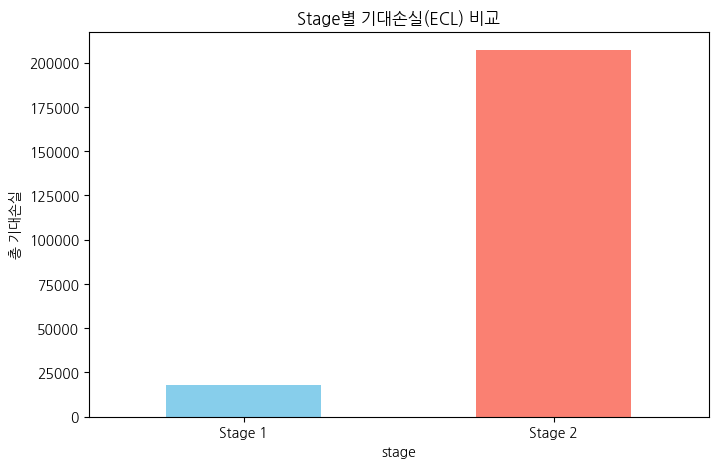

In [13]:
plt.figure(figsize=(8,5))
summary['총기대손실'].plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Stage별 기대손실(ECL) 비교')
plt.ylabel('총 기대손실')
plt.xticks(rotation=0)
plt.show()

In [14]:
df_interpret = df_credit.loc[X_test.index].copy()
df_interpret['PD'] = df_ecl['PD'].values
df_interpret['stage'] = df_ecl['stage'].values

df_interpret[['duration','credit_amount','age','installment_rate','PD','stage']].head()

,duration,credit_amount,age,installment_rate,PD,stage
115,48,3578,47,4,0.032081,Stage 1
346,13,882,23,4,0.145224,Stage 1
328,36,4473,31,4,0.432432,Stage 2
974,30,2831,33,4,0.104570,Stage 1
587,12,1289,21,4,0.273038,Stage 2


In [15]:
numeric_cols = ['duration','credit_amount','age','installment_rate','existing_credits']
comparison_numeric = df_interpret.groupby('stage')[numeric_cols].mean().round(1)
print(comparison_numeric)

         duration  credit_amount   age  installment_rate  existing_credits
stage                                                                     
Stage 1      17.4         2912.5  38.1               2.9               1.4
Stage 2      24.3         3857.7  33.8               3.2               1.4


In [16]:
categorical_cols = ['checking_account','credit_history','savings','employment','purpose']

for col in categorical_cols:
    print(f"\n=== {col} ===")
    ratio = pd.crosstab(df_interpret[col], df_interpret['stage'], normalize='columns') * 100
    print(ratio.round(1))


=== checking_account ===
stage             Stage 1  Stage 2
checking_account                  
A11                   6.0     44.6
A12                  17.2     34.9
A13                   7.5      5.4
A14                  69.4     15.1

=== credit_history ===
stage           Stage 1  Stage 2
credit_history                  
A30                 0.7      6.6
A31                 2.2      4.8
A32                50.7     60.2
A33                 3.7      9.6
A34                42.5     18.7

=== savings ===
stage    Stage 1  Stage 2
savings                  
A61         42.5     77.7
A62          8.2      6.6
A63         11.2      4.2
A64          6.7      1.2
A65         31.3     10.2

=== employment ===
stage       Stage 1  Stage 2
employment                  
A71             6.7      9.6
A72            11.2     22.3
A73            30.6     31.3
A74            28.4     13.9
A75            23.1     22.9

=== purpose ===
stage    Stage 1  Stage 2
purpose                  
A40         19.4  

In [17]:
coef_df = pd.DataFrame({
    '변수': X_train.columns,
    '계수': model.coef_[0]
}).sort_values('계수', ascending=False)

print("=== 부도 위험을 높이는 변수 TOP 10 ===")
print(coef_df.head(10))

print("\n=== 부도 위험을 낮추는 변수 TOP 10 ===")
print(coef_df.tail(10))

=== 부도 위험을 높이는 변수 TOP 10 ===
                    변수        계수
38       property_A124  0.857816
20         purpose_A46  0.736589
5     existing_credits  0.403624
2     installment_rate  0.297892
6       num_dependents  0.276453
10  credit_history_A31  0.264055
34  other_debtors_A102  0.259093
37       property_A123  0.170504
36       property_A122  0.110022
43            job_A172  0.059084

=== 부도 위험을 낮추는 변수 TOP 10 ===
                        변수        계수
15            purpose_A410 -0.719009
40  other_installment_A143 -0.771986
14             purpose_A41 -0.780011
42            housing_A153 -0.857700
29          employment_A74 -0.918335
13      credit_history_A34 -0.958059
47     foreign_worker_A202 -1.035267
26             savings_A65 -1.057300
25             savings_A64 -1.081889
9     checking_account_A14 -1.503426


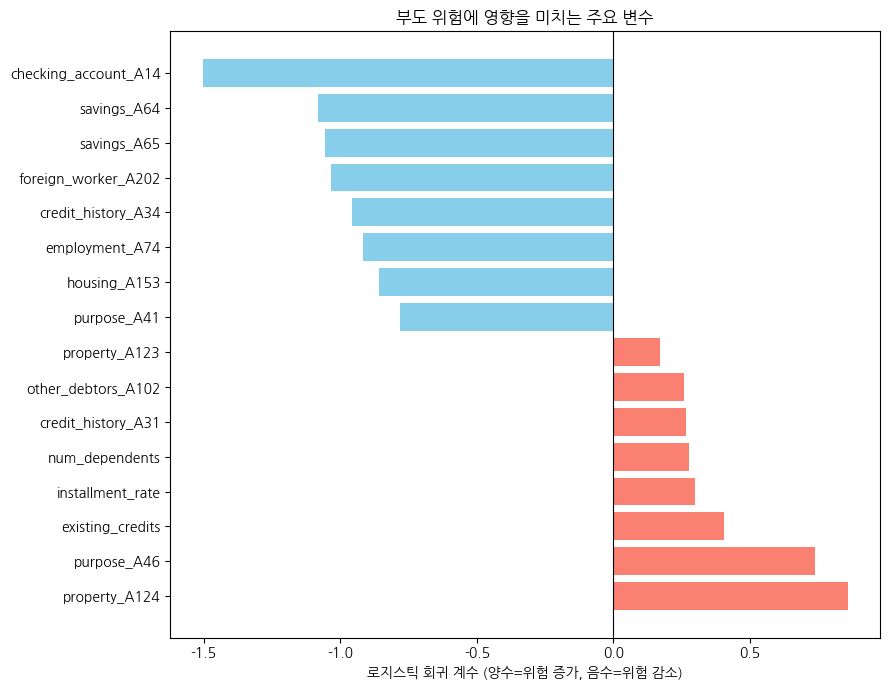

In [18]:
top_features = pd.concat([coef_df.head(8), coef_df.tail(8)])

plt.figure(figsize=(9,7))
colors = ['salmon' if x > 0 else 'skyblue' for x in top_features['계수']]
plt.barh(top_features['변수'], top_features['계수'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('로지스틱 회귀 계수 (양수=위험 증가, 음수=위험 감소)')
plt.title('부도 위험에 영향을 미치는 주요 변수')
plt.tight_layout()
plt.show()